# Feature Engineering
This notebook verifies our calculated features such as Expected Field Goal% (xFG%), Expected Points Per Shot (xPPS), and Instantaneous Shot Threat (IST)

## Import Functions


In [1]:
import pandas as pd
import numpy as np
import optuna.visualization as vis
import sys
from pathlib import Path

# Add project root to path for imports
ROOT = Path.cwd().parent  
sys.path.append(str(ROOT))
from src.data_io.maps import load_maps_npz
from src.viz.court import plot_players_by_name
from src.gradient_flows.animation import extract_plot_trajectories, animate_standard_play
from src.gradient_flows.audit import create_trial_browser, audit_final_results, generate_optimization_viz
from src.gradient_flows.animation import animate_side_by_side_courts, animate_triple_comparison # Use your existing plot function
from src.gradient_flows.poster import plot_ist_optimization_map, plot_triple_ist_shift

Error generating Pareto Front: The length of `target_names` is supposed to be 2.


## STEP 1: Test Player Maps
Add whichever players whose Quality Maps you want to see in the list below.

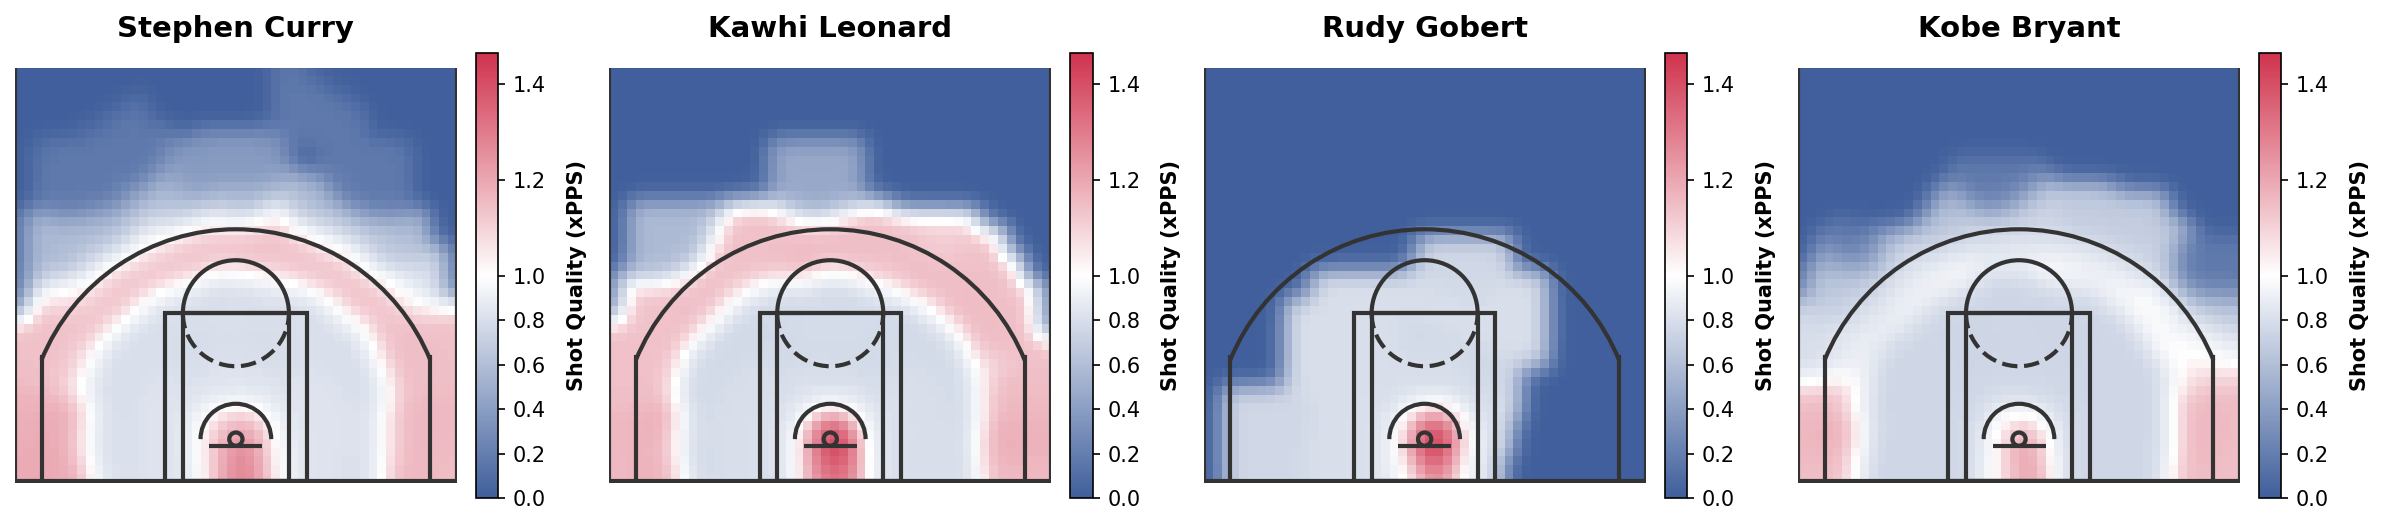

In [2]:
# Load Player Quality Maps
maps, meta = load_maps_npz("../data/demo/processed/maps_1ft_xpps.npz")

players = ['Stephen Curry', 'Kawhi Leonard', 'Rudy Gobert', 'Kobe Bryant']
plot_players_by_name(players, maps, meta)

## STEP 2: Play Viewer (Real Defense)
run after step 2 to test that real trajectories work

In [3]:
# Choose a posession to animate between 0-103
posession = 5
traj_df = pd.read_parquet("../data/demo/processed/demo_traj.parquet")
sample_play = traj_df.iloc[posession]
off_traj, def_traj, ball_traj = extract_plot_trajectories(sample_play)
animate_standard_play(off_traj, def_traj, ball_traj)

/opt/anaconda3/lib/python3.13/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




## Step 3: Choose Best Optuna Trial
Run the Code below and play with the figure to choose your favorite trial.

In [2]:
traj_df = pd.read_parquet("../data/demo/processed/demo_traj.parquet")
DB_PATH = "sqlite:///../data/demo/processed/demo-ist-tuning.db"
STUDY_NAME = "demo-ist-tuning"
generate_optimization_viz(DB_PATH, STUDY_NAME)

In [5]:
# View how Trials work visually
create_trial_browser(traj_df, DB_PATH, STUDY_NAME, animate_side_by_side_courts)

--- Best Pareto Trials ---


,trial_no,threat_reduction,smoothness,ist_weight,ist_k_smooth
3,18,1.6341,0.2984,14.686710,18.240996
2,13,1.6343,0.2984,14.956509,3.019705
0,4,1.6374,0.2978,19.941367,12.492891
1,10,1.6380,0.2975,19.739671,3.273225


interactive(children=(Dropdown(description='Optuna Trial:', options=(18, 13, 4, 10), value=18), IntSlider(valu…

## Step 4: Verify Our Models Effectiveness
Check out your final Model

In [3]:
# Load Final simulated dataset
final_df = pd.read_parquet("../data/demo/final/demo_simulated_traj.parquet")
audit_final_results(
    df=final_df,
    triple_animate_fn=animate_triple_comparison
)

interactive(children=(IntSlider(value=0, description='Select Play:', max=99), Output()), _dom_classes=('widget…

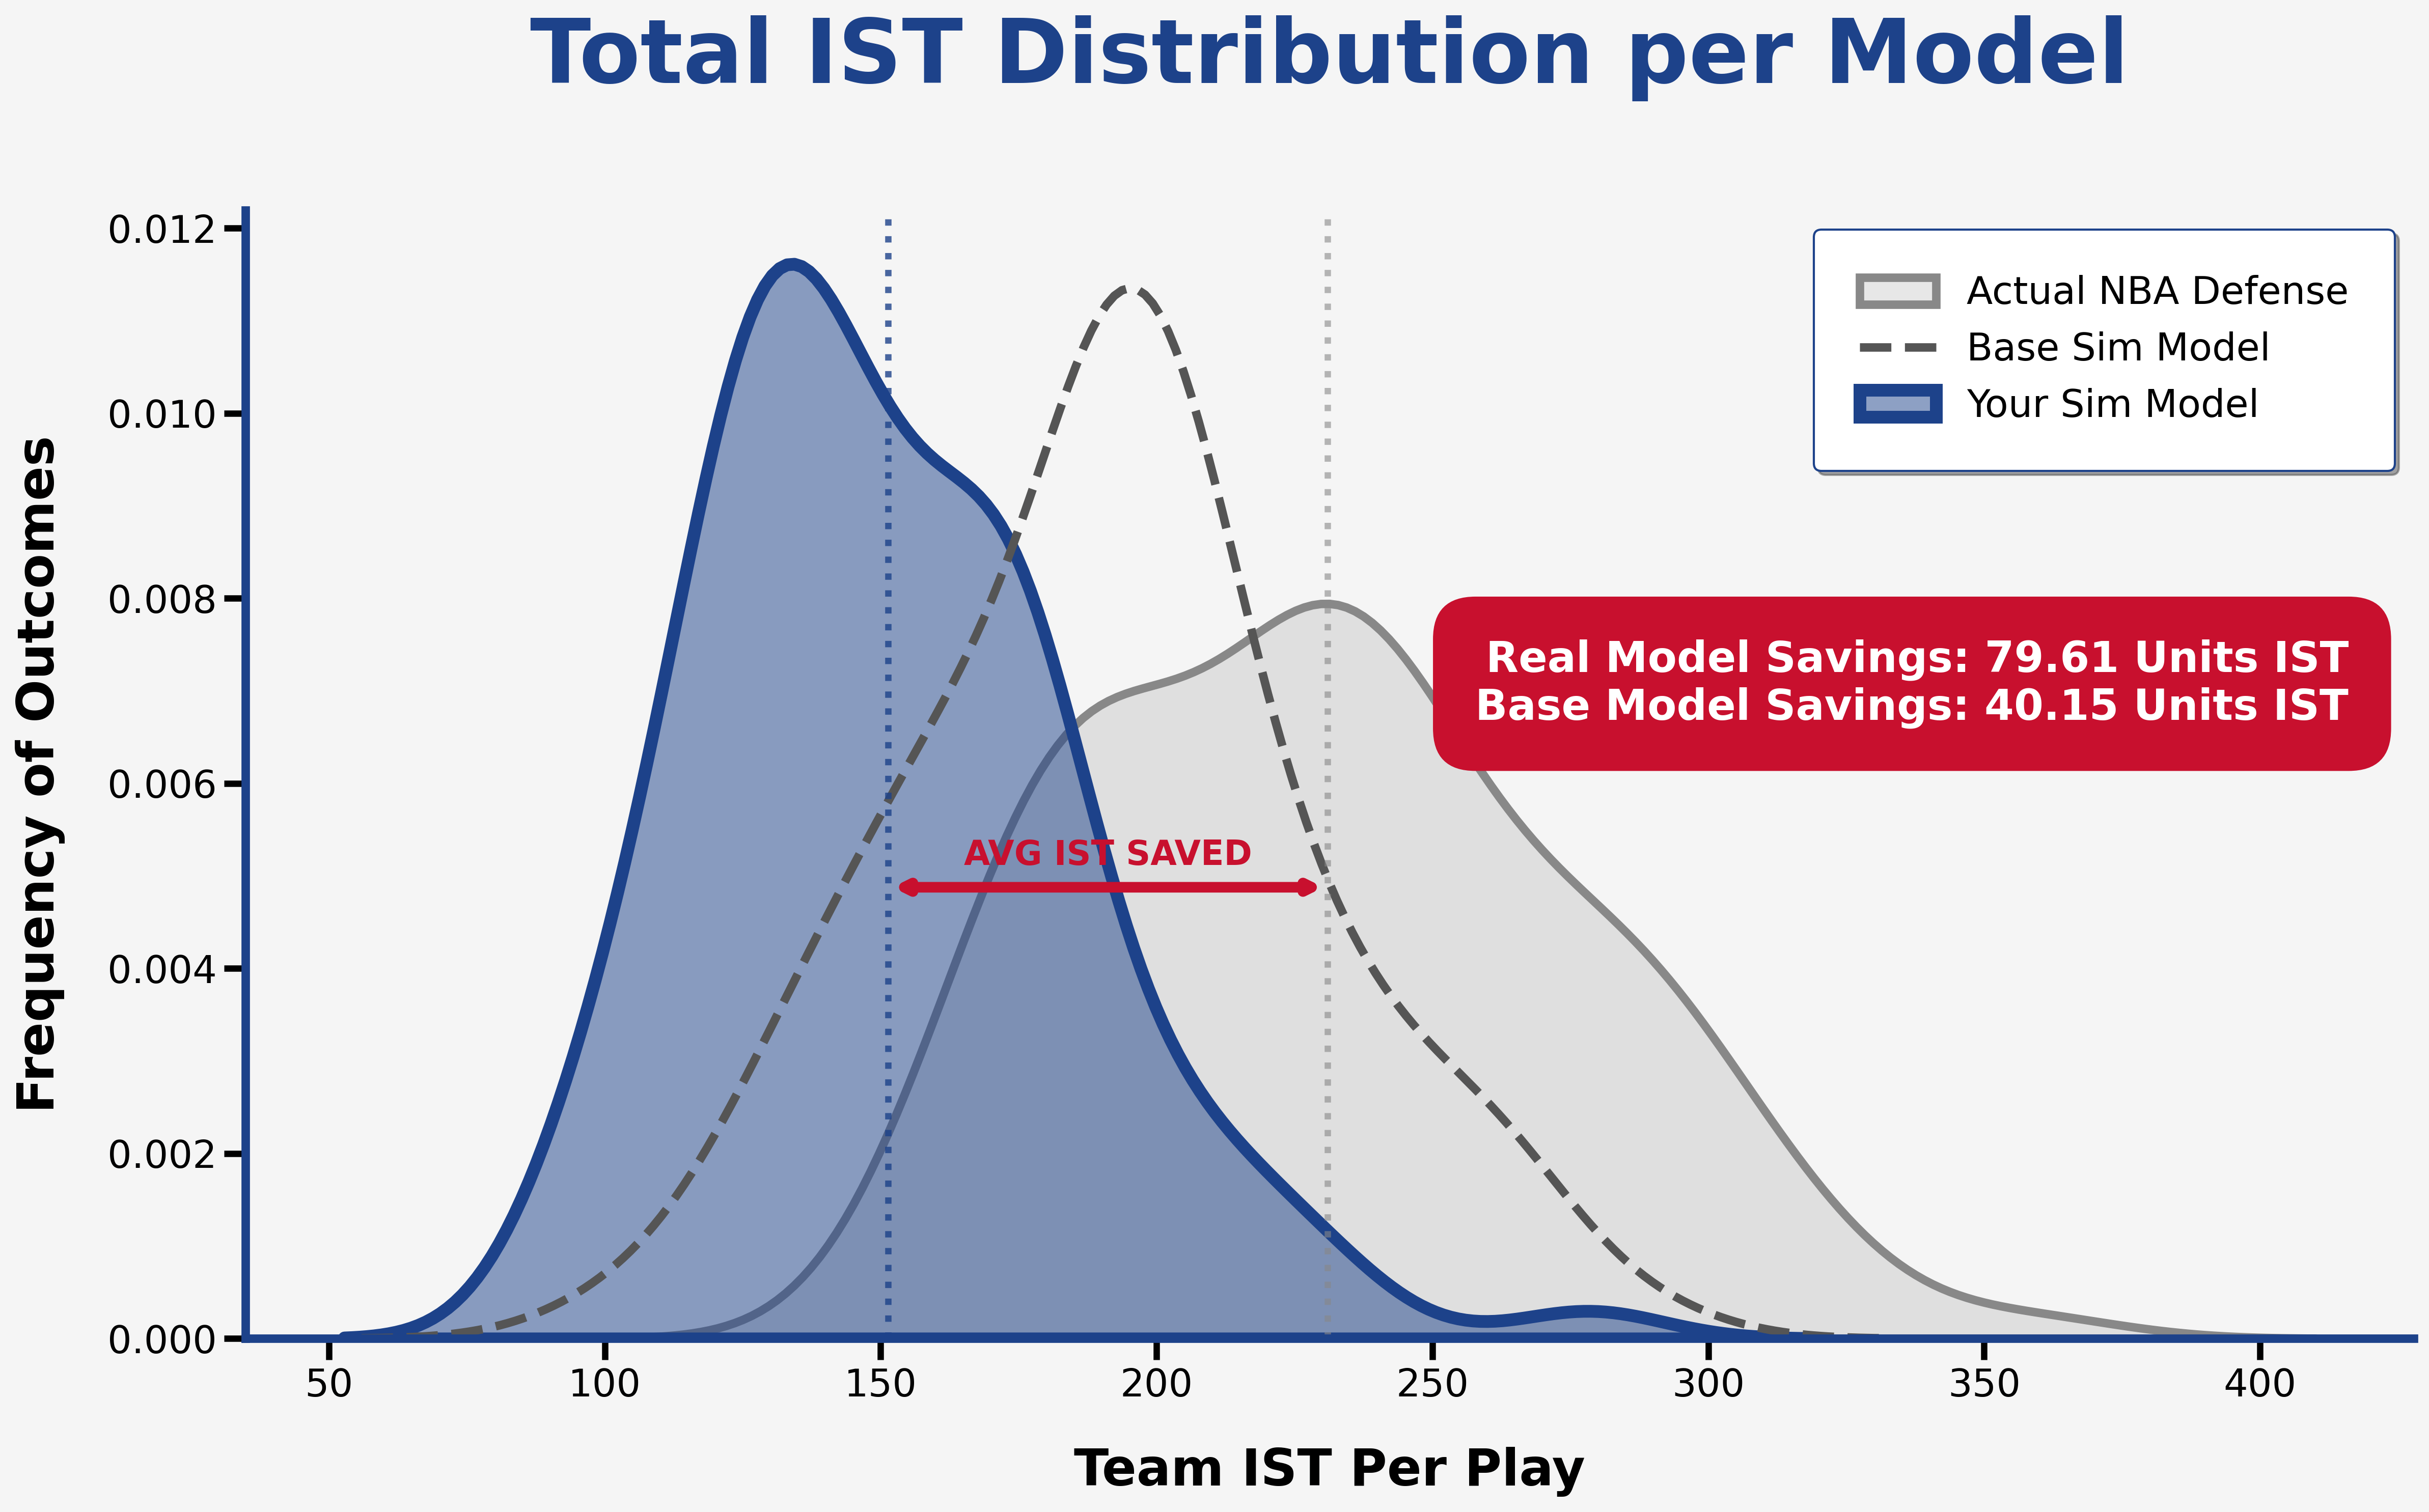

In [4]:
# Run the final Triple-Shift Dashboard
plot_triple_ist_shift(final_df)

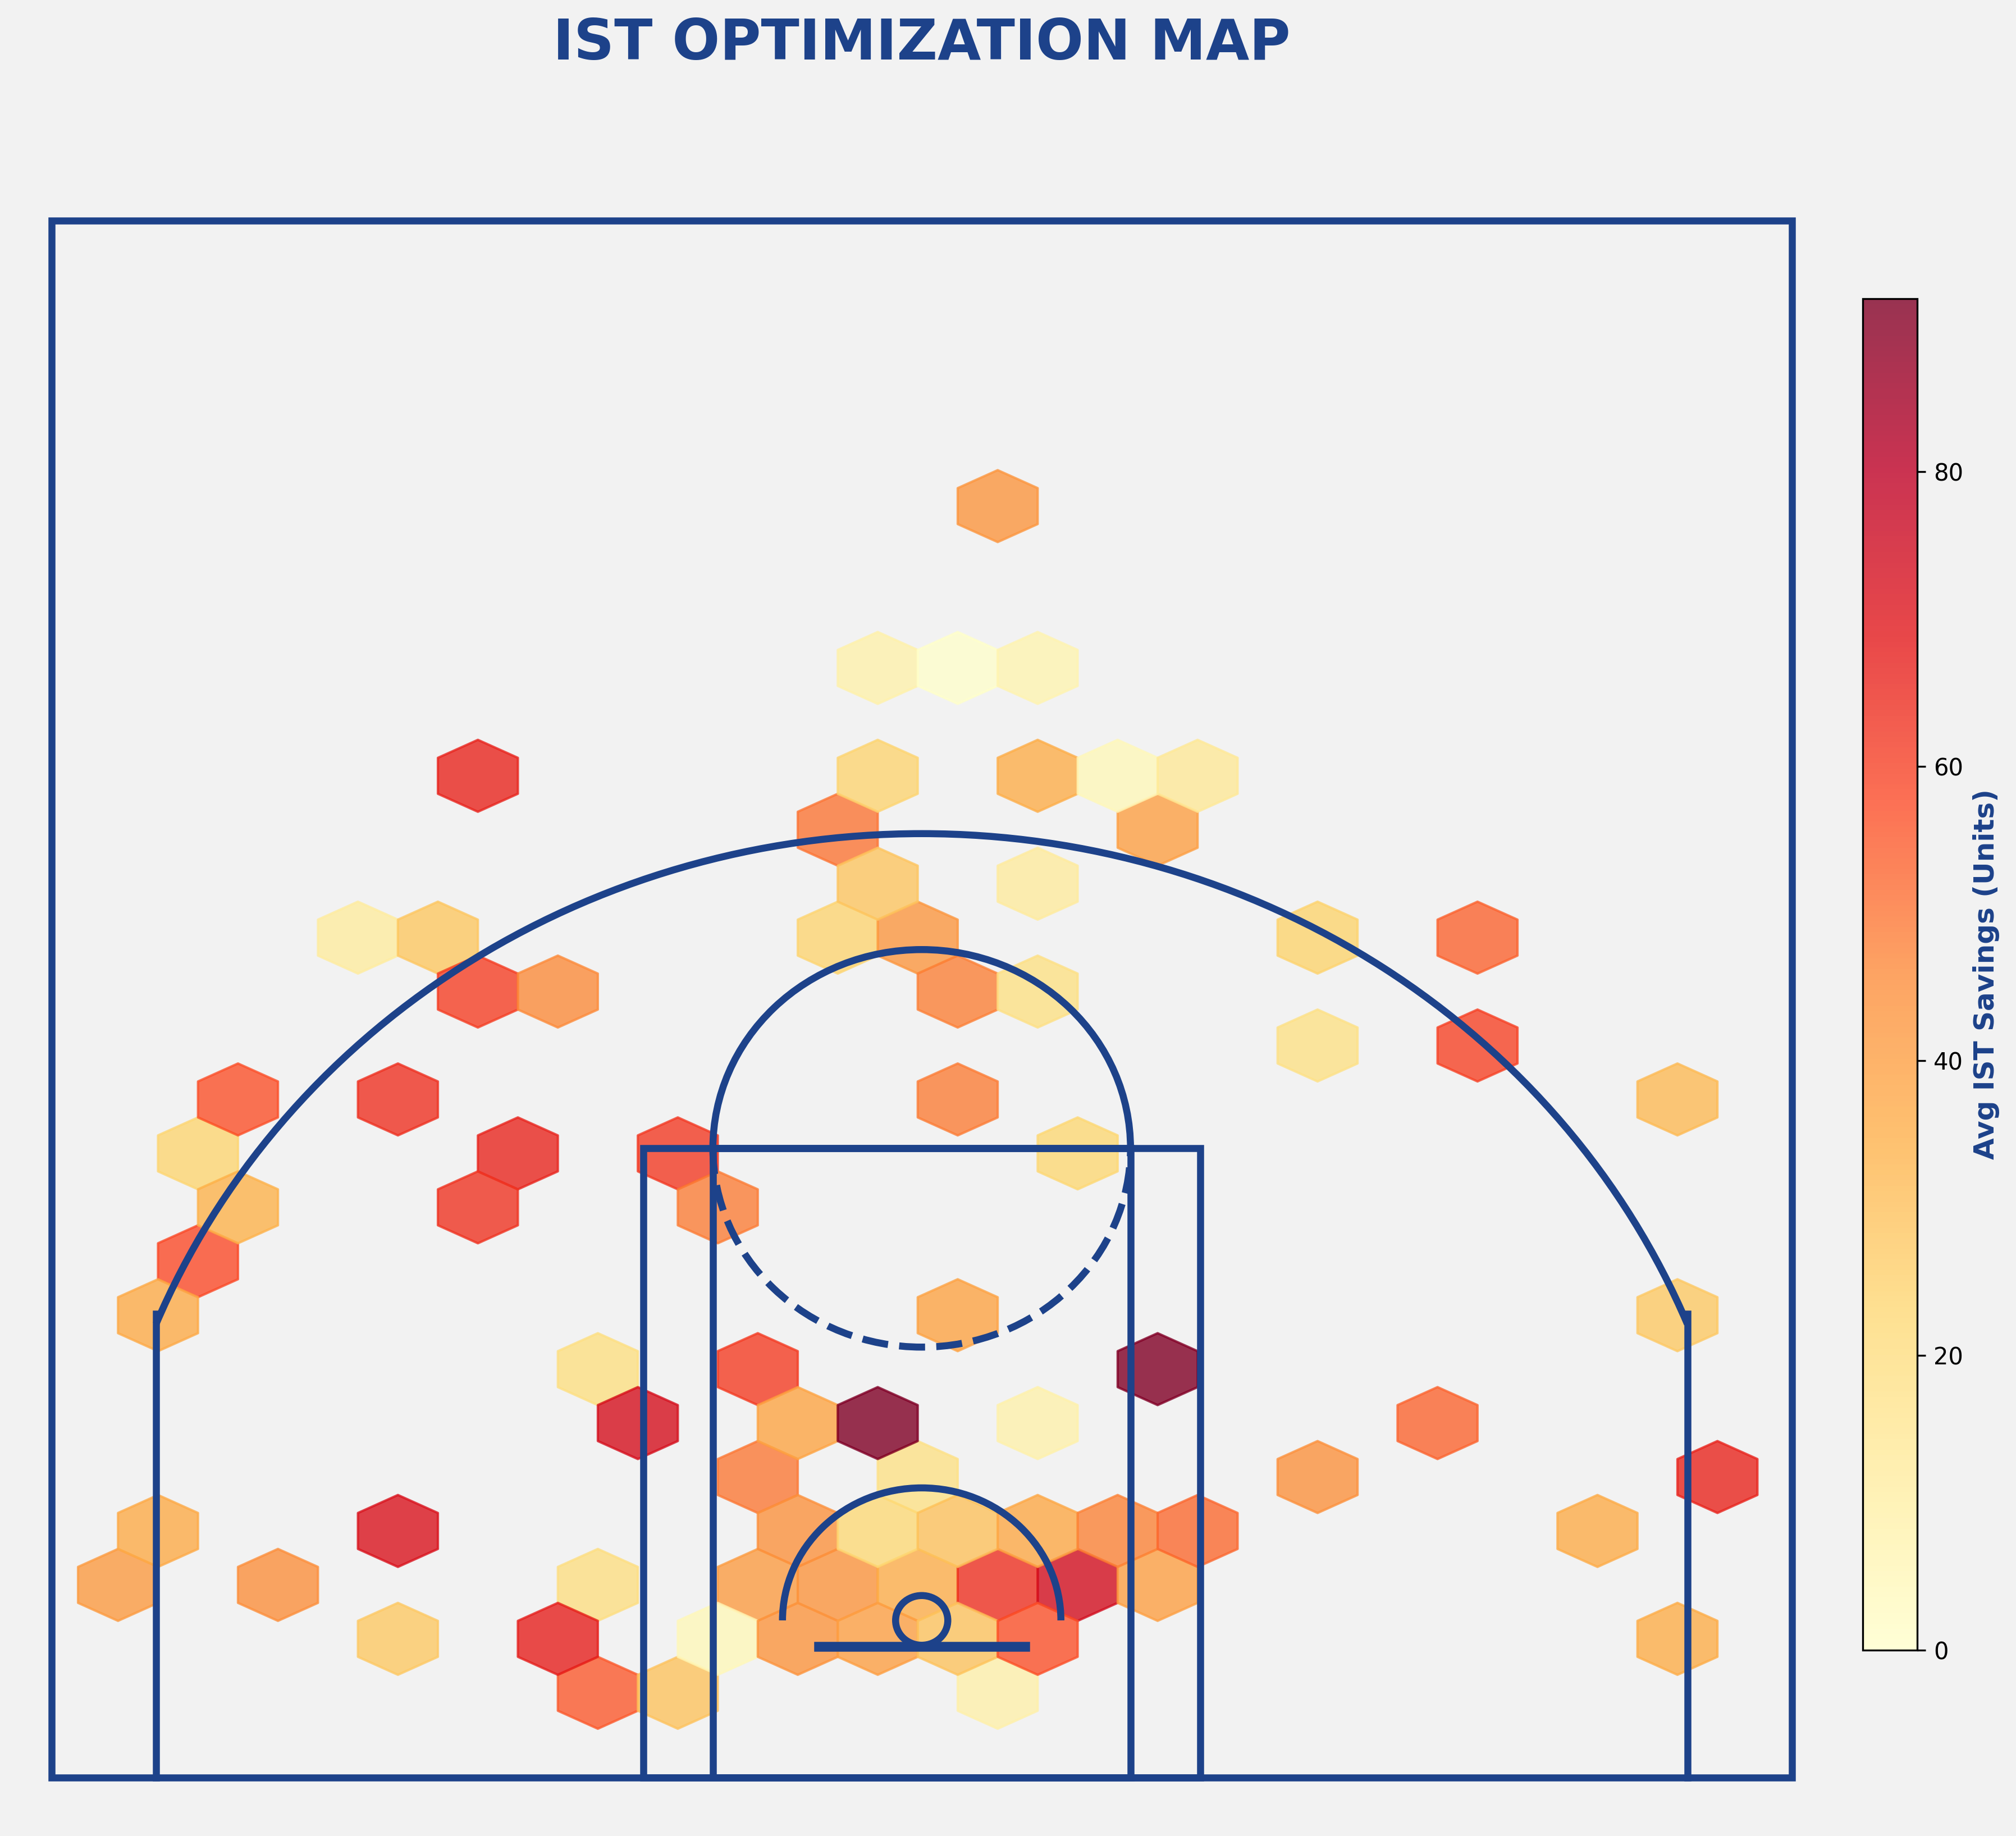

In [5]:
plot_ist_optimization_map(final_df)